# Compare CellBender vs. CellStraightener Poisson-NB Denoising

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad
import seaborn as sns
import scanpy as sc
from cellbender.remove_background.downstream import anndata_from_h5
from cellstraightener import denoise_count_matrix
import cellstraightener.utils as cs_utils

cellstraightener_dir = os.path.dirname(os.path.abspath(""))

Some datasets of use:
- tiny dataset from CellBender (CellBender/examples/remove_background/generate_tiny_10x_dataset.py): https://www.10xgenomics.com/resources/datasets/10-k-heart-cells-from-an-e-18-mouse-v-3-chemistry-3-standard-3-0-0 

- 8k PBMCs from a healthy donor (CellBender Fig2): https://www.10xgenomics.com/datasets/8-k-pbm-cs-from-a-healthy-donor-2-standard-2-1-0

In [2]:
dataset_name = "tiny_cellbender"  # options: tiny_cellbender, pbmc8k, custom
wompwomp_path = os.path.join(os.path.dirname(cellstraightener_dir), "wompwomp")  # only needed if dataset_name == "custom"
verbose = 2  # 2 debug, 1 info, 0 warning, -1 error, -2 critical
overwrite = False
cellbender_env = "/home/jrich/miniconda3/envs/cellbender"
use_cuda = False
threads = 16

# only used if dataset_name == "custom", otherwise these variables will be set in the if/elif blocks below
original_matrix_custom = None
matrix_cleaned_cellbender_custom = None
matrix_cleaned_cs_poisson_custom = None
model_pkl_custom = None
cellbender_epochs_custom = None
cellbender_total_droplets_custom = None
expected_cells_custom = None
cs_empty_threshold_custom = None
min_genes_custom = None
min_cells_custom = None
max_mt_percentage_custom = None

In [3]:
data_dir = os.path.join(cellstraightener_dir, "notebooks", "data", dataset_name)
os.makedirs(data_dir, exist_ok=True)

out_dir = os.path.join(cellstraightener_dir, "notebooks", "output", dataset_name)
os.makedirs(out_dir, exist_ok=True)

if dataset_name == "tiny_cellbender":
    original_matrix = f"{data_dir}/tiny_raw_feature_bc_matrix.h5ad"
    matrix_cleaned_cellbender = f"{data_dir}/tiny_output_cellbender.h5"
    matrix_cleaned_cs_poisson = f"{data_dir}/tiny_output_cs_poisson.h5"
    model_pkl = "Adult_Mouse_Gut.pkl"  # path to celltypist model pkl file - this is a mouse heart dataset, but this is really just for debugging anyways
    
    if not os.path.exists(original_matrix):
        raise FileNotFoundError(f"Original matrix file not found: {original_matrix}. Create with `python generate_tiny_10x_dataset.py` (see https://github.com/broadinstitute/CellBender):")
    
    cellbender_epochs = 2
    cellbender_total_droplets = 2000
    expected_cells = 500
    cs_empty_threshold = 1000
    min_genes = 5
    min_cells = 3
    max_mt_percentage = 50
elif dataset_name == "pbmc8k":
    original_matrix = f"{data_dir}/pbmc8k_raw_gene_bc_matrices_h5.h5"
    matrix_cleaned_cellbender = f"{data_dir}/pbmc8k_output_cellbender.h5"
    matrix_cleaned_cs_poisson = f"{data_dir}/pbmc8k_output_cs_poisson.h5"
    model_pkl = "Immune_All_High.pkl"  # path to celltypist model pkl file

    if not os.path.exists(original_matrix):
        !wget -O {original_matrix} https://cf.10xgenomics.com/samples/cell-exp/2.1.0/pbmc8k/pbmc8k_raw_gene_bc_matrices_h5.h5
    
    cellbender_epochs = 5
    cellbender_total_droplets = 2000
    expected_cells = 500
    cs_empty_threshold = 10
    min_genes = 100
    min_cells = 3
    max_mt_percentage = 25
else:
    original_matrix = original_matrix_custom
    matrix_cleaned_cellbender = matrix_cleaned_cellbender_custom
    matrix_cleaned_cs_poisson = matrix_cleaned_cs_poisson_custom
    model_pkl = model_pkl_custom
    cellbender_epochs = cellbender_epochs_custom
    cellbender_total_droplets = cellbender_total_droplets_custom
    expected_cells = expected_cells_custom
    cs_empty_threshold = cs_empty_threshold_custom
    min_genes = min_genes_custom
    min_cells = min_cells_custom
    max_mt_percentage = max_mt_percentage_custom

## Raw

In [4]:
adata_raw = ad.read_h5ad(original_matrix)

## Knee plot - use this output to estimate cs_empty_threshold

UMI cutoff for expected cells (500): 2100.00


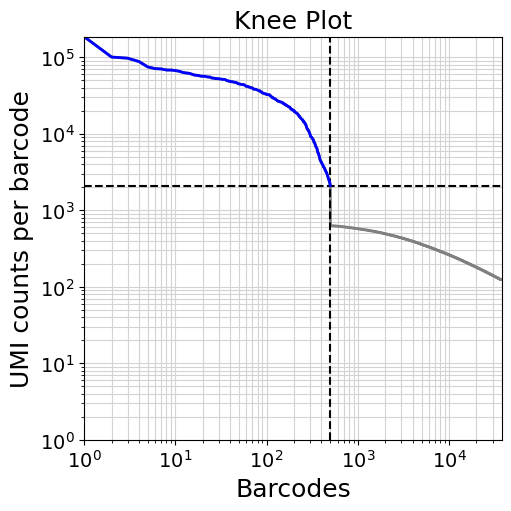

In [5]:
cs_utils.knee_plot(adata_raw, expected_cells=expected_cells, out_path=os.path.join(out_dir, "knee_plot.png"))

## Cellstraightener

In [ ]:
%%time

# import importlib
# import cellstraightener.celltype_ambient
# importlib.reload(cellstraightener.celltype_ambient)
# from cellstraightener.celltype_ambient import denoise_count_matrix

if not os.path.exists(matrix_cleaned_cs_poisson) or overwrite:
    adata = adata_raw.copy()
    adata = cs_utils.infer_empty_droplets(adata, method="threshold", umi_cutoff=None, expected_cells=expected_cells, verbose=verbose)

    sc.pp.filter_cells(adata, min_genes=min_genes)
    sc.pp.filter_genes(adata, min_cells=min_cells)

    adata.var["mt"] = adata.var_names.str.upper().str.startswith("MT-")
    sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)
    if max_mt_percentage is not None:
        adata = adata[adata.obs.pct_counts_mt < max_mt_percentage, :]

    adata.layers["counts"] = adata.X.copy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)

    adata = cs_utils.determine_cell_types(adata, model_pkl=model_pkl, filter_empty=True, verbose=verbose)
    
    _ = denoise_count_matrix(adata, adata_out=matrix_cleaned_cs_poisson, K=3, max_iter=40, beta=0.3, eps=1e-9, empty_droplet_method="threshold", expected_cells=expected_cells, cell_ambient_fraction=0.01, verbose=verbose)

CPU times: user 65 μs, sys: 1 μs, total: 66 μs
Wall time: 88.7 μs


In [8]:
adata_cellstraightener = ad.read_h5ad(matrix_cleaned_cs_poisson)
adata_cellstraightener = adata_cellstraightener[~adata_cellstraightener.obs["is_empty"]].copy()

## CellBender

In [9]:
%%time
if not os.path.exists(matrix_cleaned_cellbender) or overwrite:
     conda_run_flag = "-p" if "/" in cellbender_env else "-n"
     runtime = "--cuda" if use_cuda else f"--cpu-threads {threads}"
     !conda run {conda_run_flag} {cellbender_env} cellbender remove-background \
          --input {original_matrix} \
          --output {matrix_cleaned_cellbender} \
          --expected-cells {expected_cells} \
          --total-droplets-included {cellbender_total_droplets} \
          --epochs {cellbender_epochs} \
          --fpr {cellbender_fpr} \
          {runtime}

CPU times: user 645 μs, sys: 0 ns, total: 645 μs
Wall time: 591 μs


In [10]:
adata_cellbender_with_empty_droplets = anndata_from_h5(matrix_cleaned_cellbender)
adata_cellbender = adata_cellbender_with_empty_droplets[adata_cellbender_with_empty_droplets.obs['cell_probability'] > 0.5]

In [11]:
print(f"Raw:\n{adata_raw}\n\n")
print(f"CellBender:\n{adata_cellbender}\n\n")
print(f"CellStraightener:\n{adata_cellstraightener}\n\n")

Raw:
AnnData object with n_obs × n_vars = 37760 × 100
    var: 'gene_id', 'genome', 'feature_type'
    uns: 'cellranger_version'


CellBender:
View of AnnData object with n_obs × n_vars = 488 × 100
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency'
    var: 'ambient_expression', 'features_analyzed_inds', 'feature_type', 'genome', 'gene_id', 'cellbender_analyzed'
    uns: 'cell_size_lognormal_std', 'empty_droplet_size_lognormal_loc', 'empty_droplet_size_lognormal_scale', 'swapping_fraction_dist_params', 'estimator', 'fraction_data_used_for_testing', 'learning_curve_learning_rate_epoch', 'learning_curve_learning_rate_value', 'learning_curve_test_elbo', 'learning_curve_test_epoch', 'learning_curve_train_elbo', 'learning_curve_train_epoch', 'target_false_positive_rate'
    obsm: 'gene_expression_encoding'


CellStraightener:
AnnData object with n_obs × n_vars = 416 × 100
    obs: 'is_empty', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt

## UpSet plot of retained cells

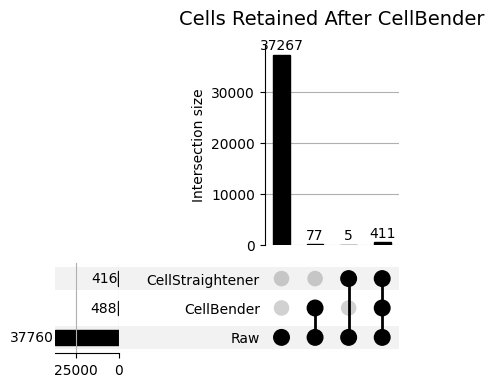

In [12]:
upset_data_dict = {
    "Raw": set(adata_raw.obs_names),
    "CellBender": set(adata_cellbender.obs_names),
    "CellStraightener": set(adata_cellstraightener.obs_names),
}

_ = cs_utils.make_upset_plot(upset_data_dict, title="Cells Retained After CellBender", out_path=os.path.join(out_dir, "cells_retained_upset.png"))

## Scatterplot of cell x gene expression differences

In [13]:
# cs_utils.plot_difference_heatmap(adata_cellbender, adata_cellstraightener, cell_subset=50, gene_subset=70, show_cell_names=False, title="CellBender - CellStraightener Expression Differences", out_path=os.path.join(out_dir, "cellbender_vs_cellstraightener_heatmap.png"))

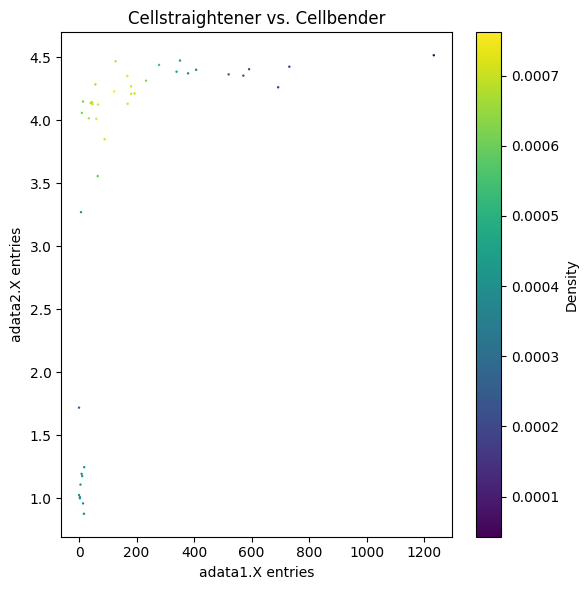

In [14]:
cs_utils.plot_matrix_scatterplot(adata_cellbender, adata_cellstraightener, title="Cellstraightener vs. Cellbender", sample_frac=0.001, out_path=os.path.join(out_dir, "cellstraightener_vs_cellbender_expression_scatterplot.png"), show=True)

## Histogram of per-cell Pearson correlations

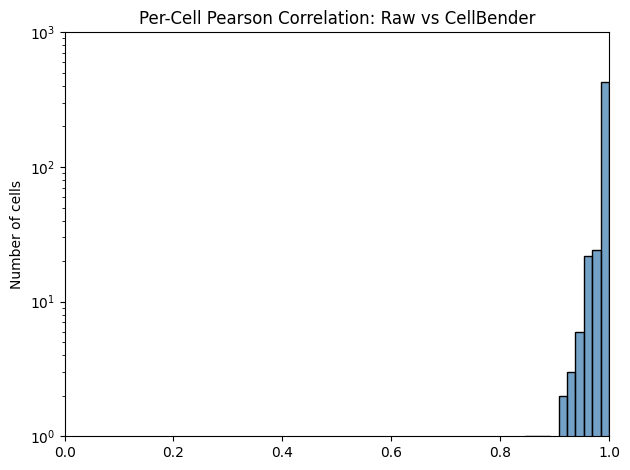

In [14]:
cs_utils.plot_per_cell_correlation(adata_raw, adata_cellbender, title="Per-Cell Pearson Correlation: Raw vs CellBender", out_path=os.path.join(out_dir, "raw_vs_cellbender_per_cell_correlation.png"))

## stop here for tiny dataset

In [15]:
if dataset_name == "tiny_cellbender":
    sys.exit()

SystemExit: 

## Alluvial plot of cluster differences

In [ ]:
cs_utils.run_scanpy_preprocessing_and_clustering(adata_raw)
cs_utils.determine_cell_types(adata_raw, method="celltypist", model_pkl=model_pkl)

In [ ]:
# # dummy cell types
# adata_raw.obs["celltype"] = np.random.randint(1, 4, size=len(adata_raw.obs))
# adata_cellbender.obs["celltype"] = np.random.randint(1, 4, size=len(adata_cellbender.obs))
# adata_cellstraightener.obs["celltype"] = np.random.randint(1, 4, size=len(adata_cellstraightener.obs))

col_names = ("raw", "cellbender", "cellstraightener")
df = cs_utils.plot_alluvial(adata_raw, adata_cellbender, adata_cellstraightener, names=col_names, merged_df_csv=os.path.join(out_dir, "alluvial_df.csv"), out_path=os.path.join(out_dir, "cluster_assignment_alluvial.png"), wompwomp_path=wompwomp_path)

conda run -n wompwomp_env /home/jrich/Desktop/wompwomp/exec/wompwomp plot_alluvial --df /home/jrich/Desktop/cellstraightener/notebooks/output/tiny_cellbender/alluvial_df.csv --graphing_columns raw cellbender cellstraightener --coloring_algorithm left -o /home/jrich/Desktop/cellstraightener/notebooks/output/tiny_cellbender/cluster_assignment_alluvial.png


/tmp/ipykernel_2036329/151824394.py:3: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_cellbender.obs["celltype"] = np.random.randint(1, 4, size=len(adata_cellbender.obs))


## Dot plots